
Doğruluk: %100.0

Tahminler (Ham):
[[0.04699259]
 [0.94506092]
 [0.94367521]
 [0.0738788 ]]

Tahminler (Yuvarlanmış):
[[0.]
 [1.]
 [1.]
 [0.]]


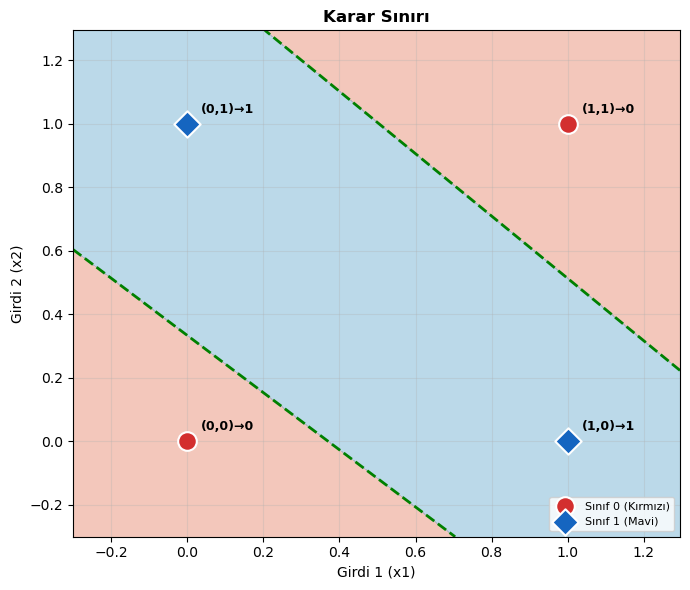

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([[0], [1], [1], [0]])

input_size = 2
hidden_size = 2
output_size = 1

w1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

w2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

lr = 0.01
epochs = 100000

for epoch in range(epochs):
    z1 = np.dot(X, w1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, w2) + b2
    y_pred = sigmoid(z2)
    error = y_pred - y

    delta2 = error * sigmoid_derivative(z2)
    dw2 = np.dot(a1.T, delta2)
    db2 = np.sum(delta2, axis=0, keepdims=True)
    delta1 = np.dot(delta2, w2.T) * sigmoid_derivative(z1)
    dw1 = np.dot(X.T, delta1)
    db1 = np.sum(delta1, axis=0, keepdims=True)

    w2 -= lr * dw2
    b2 -= lr * db2
    w1 -= lr * dw1
    b1 -= lr * db1

z1_son     = np.dot(X, w1) + b1
a1_son     = sigmoid(z1_son)
z2_son     = np.dot(a1_son, w2) + b2
son_pred   = sigmoid(z2_son)
dogruluk   = np.mean(son_pred.round() == y) * 100

print(f"\nDoğruluk: %{dogruluk:.1f}")
print("\nTahminler (Ham):")
print(son_pred)
print("\nTahminler (Yuvarlanmış):")
print(son_pred.round())

fig, ax2 = plt.subplots(figsize=(7, 6))

h = 0.005
xx, yy = np.meshgrid(np.arange(-0.3, 1.3, h),
                     np.arange(-0.3, 1.3, h))
grid   = np.c_[xx.ravel(), yy.ravel()]
z1g    = sigmoid(np.dot(grid, w1) + b1)
pg     = sigmoid(np.dot(z1g, w2) + b2).reshape(xx.shape)

ax2.contourf(xx, yy, pg, levels=[0, 0.5, 1],
             cmap=plt.cm.RdBu, alpha=0.45)
ax2.contour(xx, yy, pg, levels=[0.5],
            colors='green', linewidths=2, linestyles='--')

renkler  = ['#d32f2f', '#1565c0', '#1565c0', '#d32f2f']
isaret   = ['o', 'D', 'D', 'o']
etiketler = ['Sınıf 0 (Kırmızı)', 'Sınıf 1 (Mavi)', '', '']
for i in range(4):
    ax2.scatter(X[i,0], X[i,1], c=renkler[i], marker=isaret[i],
                s=180, zorder=5, edgecolors='white', linewidth=1.5,
                label=etiketler[i] if etiketler[i] else None)
    ax2.annotate(f'({X[i,0]},{X[i,1]})→{y[i,0]}',
                 (X[i,0], X[i,1]),
                 textcoords="offset points", xytext=(10, 8),
                 fontsize=9, fontweight='bold')

ax2.set_title('Karar Sınırı', fontweight='bold')
ax2.set_xlabel('Girdi 1 (x1)')
ax2.set_ylabel('Girdi 2 (x2)')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()